<a href="https://colab.research.google.com/github/renwxyz/quantify-vocal-pitch-poc/blob/main/quantify_vocal_pitch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# POC: Evaluasi Ketepatan Nada Vokal Sopran terhadap MIDI Referensi

Notebook ini adalah **rewrite bersih** dari POC sebelumnya. Semua fungsi didefinisikan sekali saja,
dan sel-sel disusun agar bisa dijalankan berurutan dari atas ke bawah tanpa error.

**Tujuan:** mengukur seberapa tepat 3 rekaman vokal sopran (part lagu yang sama) terhadap nada
referensi MIDI, dan menjawab apakah CREPE/pYIN mumpuni sebagai alat tolak ukur ketepatan vokal.
Prinsip: cepat, akurat, dapat dijelaskan, tidak overengineered.

**Alur:**
1. Setup & install dependencies
2. Definisi semua fungsi
3. Upload file
4. Tahap 1 — Inspeksi & sanity check
5. Tahap 1.5 — Deteksi offset otomatis
6. Tahap 2 — Ground truth MIDI (trimmed)
7. Tahap 3 — Ekstraksi f0 vokal (CREPE + pYIN)
8. Tahap 4 — Alignment (DTW, dengan direct time-mapping sebagai fallback)
9. Tahap 5 — Metrik (cents deviation, MACE, RMS, %in-tune)
10. Diagnostic tambahan
11. Tahap 6 — Visualisasi
12. Tahap 7 — Kesimpulan
13. Export hasil ke CSV


## 1. Setup & Install Dependencies

In [1]:
# Install dependencies (Colab)
!pip install -q crepe librosa pretty_midi soundfile matplotlib pandas numpy scipy


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 56.2 MB/s eta 0:00:00


In [2]:
!git clone https://github.com/renwxyz/quantify-vocal-pitch-poc.git

Cloning into 'quantify-vocal-pitch-poc'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import pretty_midi
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# CREPE pakai TensorFlow di belakang layar
import crepe

# ===== Konfigurasi global (semua ambang & parameter ada di sini, gampang diubah) =====
HOP_MS = 10                    # resolusi waktu (ms) untuk semua kontur f0 -> harus konsisten di semua tahap
HOP_S = HOP_MS / 1000.0

SOPRANO_FMIN = 220.0           # ~A3, buffer di bawah C4 untuk jaga-jaga nada rendah
SOPRANO_FMAX = 1200.0          # buffer di atas C6 untuk jaga-jaga nada tinggi/overtone

CREPE_CONF_THRESHOLD = 0.5     # buang frame CREPE dengan confidence < ini
INTUNE_CENTS_THRESHOLD = 50    # +-50 cents = setengah semitone, ambang umum "in-tune"

OFFSET_SEARCH_RANGE_S = (0, 30)   # rentang pencarian offset (detik) -> dibatasi ke awal lagu, hindari false positive di ujung lagu (ritardando)
OFFSET_SEARCH_STEP_S = 0.05       # resolusi pencarian offset, halus supaya presisi
BUFFER_S = 1.0                    # buffer ekstra di akhir window trim MIDI (jaga-jaga durasi vokal sedikit lebih panjang)

USE_DTW = True                 # True = pakai DTW (menangani drift lokal per not). False = direct time-mapping.

print("Konfigurasi siap. HOP_MS =", HOP_MS, "ms")


Konfigurasi siap. HOP_MS = 10 ms


## 2. Definisi Semua Fungsi (versi final)

Semua fungsi dikonsolidasikan di satu tempat, masing-masing hanya didefinisikan sekali,
dan sudah termasuk seluruh perbaikan dari sesi debugging sebelumnya:
- `midi_to_f0_contour`: mengecualikan frame dengan not yang tumpang tindih (overlap) dari ground truth.
- `find_best_offset_refined`: cross-correlation kontur pitch dalam skala cents relatif, dibatasi ke rentang pencarian yang masuk akal.
- `compute_cents_metrics`: octave-wrap correction sebagai safety net.


In [24]:
# ============================================================
# Ekstraksi f0 — CREPE
# ============================================================
def extract_f0_crepe(y, sr, hop_ms=HOP_MS, model_capacity="small"):
    """Ekstraksi f0 pakai CREPE. model_capacity: 'tiny'|'small'|'medium'|'large'|'full'.
    Mulai dari 'small' untuk kecepatan POC; naikkan ke 'full' kalau akurasi kurang.
    """
    time, frequency, confidence, _ = crepe.predict(
        y, sr, model_capacity=model_capacity,
        step_size=hop_ms, viterbi=True, verbose=0
    )
    return pd.DataFrame({"time": time, "f0_hz": frequency, "confidence": confidence})


# ============================================================
# Ekstraksi f0 — pYIN
# ============================================================
def extract_f0_pyin(y, sr, hop_s=HOP_S, fmin=SOPRANO_FMIN, fmax=SOPRANO_FMAX):
    hop_length = int(round(hop_s * sr))
    f0, voiced_flag, voiced_prob = librosa.pyin(
        y, fmin=fmin, fmax=fmax, sr=sr, hop_length=hop_length
    )
    times = librosa.times_like(f0, sr=sr, hop_length=hop_length)
    df = pd.DataFrame({
        "time": times, "f0_hz": f0,
        "voiced_flag": voiced_flag, "voiced_prob": voiced_prob,
    })
    # Frame unvoiced -> NaN (bukan pitch valid)
    df["f0_hz_filtered"] = np.where(df["voiced_flag"] == True, df["f0_hz"], np.nan)
    return df


# ============================================================
# Ground truth f0 dari MIDI (dengan exclude overlap-not)
# ============================================================
def midi_to_f0_contour(midi_path, hop_s, total_duration=None, instrument_filter=None):
    """Ubah not-not MIDI jadi kontur f0 (Hz) step-function.

    Fix penting: frame dengan >1 not aktif bersamaan (overlap/tumpang tindih, biasanya
    bug encoding MIDI) di-set NaN dan dikecualikan dari ground truth -- bukan ditimpa/
    ditebak not mana yang benar.
    """
    pm = pretty_midi.PrettyMIDI(midi_path)
    if total_duration is None:
        total_duration = pm.get_end_time()

    n_steps = int(np.ceil(total_duration / hop_s)) + 1
    times = np.arange(n_steps) * hop_s
    f0 = np.full(n_steps, np.nan)
    note_num = np.full(n_steps, np.nan)
    note_count = np.zeros(n_steps, dtype=int)

    all_notes = []
    for i, inst in enumerate(pm.instruments):
        if inst.is_drum:
            continue
        if instrument_filter is not None:
            if isinstance(instrument_filter, int):
                if i != instrument_filter:
                    continue
            elif isinstance(instrument_filter, str):
                if instrument_filter.lower() not in inst.name.lower():
                    continue
        all_notes.extend(inst.notes)

    for note in all_notes:
        start_idx = max(0, int(round(note.start / hop_s)))
        end_idx = min(n_steps, int(round(note.end / hop_s)))
        freq = 440.0 * (2.0 ** ((note.pitch - 69) / 12.0))
        f0[start_idx:end_idx] = freq
        note_num[start_idx:end_idx] = note.pitch
        note_count[start_idx:end_idx] += 1

    # Frame dengan >1 not aktif bersamaan -> ambigu, jangan dipakai sebagai ground truth
    overlap_mask = note_count > 1
    f0[overlap_mask] = np.nan
    note_num[overlap_mask] = np.nan

    n_overlap = overlap_mask.sum()
    if n_overlap > 0:
        print(f"PERINGATAN: {n_overlap} frame terdeteksi overlap not (ambigu) -> "
              f"di-set NaN, dikecualikan dari ground truth.")

    return pd.DataFrame({
        "time": times, "midi_note": note_num,
        "f0_midi_hz": f0, "note_count": note_count,
    })


# ============================================================
# Deteksi offset otomatis (cross-correlation kontur pitch, skala cents relatif)
# ============================================================
def find_best_offset_refined(vocal_f0_series, midi_f0_full, hop_s,
                              search_range=OFFSET_SEARCH_RANGE_S,
                              search_step_s=OFFSET_SEARCH_STEP_S):
    """Cari offset (titik mulai bagian vokal di lagu MIDI penuh) via cross-correlation
    kontur pitch dalam skala cents RELATIF (bukan Hz mentah) -> netral terhadap oktaf absolut.
    Pencarian dibatasi ke `search_range` untuk hindari false positive (mis. di ujung lagu
    saat ada ritardando/not sustain yang gampang match secara kebetulan).
    """
    def to_relative_cents(f0):
        f0 = np.array(f0, dtype=float)
        valid = ~np.isnan(f0) & (f0 > 0)
        if valid.sum() == 0:
            return np.zeros_like(f0)
        ref = np.nanmedian(f0[valid])
        cents = np.full_like(f0, 0.0)
        cents[valid] = 1200 * np.log2(f0[valid] / ref)
        cents[~valid] = 0.0
        return cents

    vocal_cents = to_relative_cents(vocal_f0_series)
    midi_cents_full = to_relative_cents(midi_f0_full)

    L = len(vocal_cents)
    start_frame = int(search_range[0] / hop_s)
    end_frame = int(search_range[1] / hop_s)
    step_frames = max(1, int(round(search_step_s / hop_s)))

    scores, offsets = [], []
    for start in range(start_frame, min(end_frame, len(midi_cents_full) - L), step_frames):
        window = midi_cents_full[start:start + L]
        v = vocal_cents - vocal_cents.mean()
        w = window - window.mean()
        denom = np.linalg.norm(v) * np.linalg.norm(w)
        score = float(np.dot(v, w) / denom) if denom > 1e-9 else 0.0
        scores.append(score)
        offsets.append(start * hop_s)

    df_scores = pd.DataFrame({"offset_time": offsets, "score": scores})
    best_row = df_scores.loc[df_scores["score"].idxmax()]
    return best_row["offset_time"], df_scores


# ============================================================
# Alignment — direct time-mapping (fallback/pembanding)
# ============================================================
def align_direct(df_vocal_f0, df_midi_gt):
    """Direct time-mapping: nearest-index lookup MIDI ground truth ke timestamp vokal.
    (Pakai nearest-index, bukan np.interp, supaya rest/NaN tidak ikut terinterpolasi.)
    """
    idx = np.searchsorted(df_midi_gt["time"].values, df_vocal_f0["time"].values, side="right") - 1
    idx = np.clip(idx, 0, len(df_midi_gt) - 1)
    f0_midi_aligned = df_midi_gt["f0_midi_hz"].values[idx]
    note_aligned = df_midi_gt["midi_note"].values[idx]
    out = df_vocal_f0.copy()
    out["f0_midi_hz"] = f0_midi_aligned
    out["midi_note"] = note_aligned
    return out


# ============================================================
# Alignment — DTW (default, menangani drift lokal per not)
# ============================================================
def align_dtw(df_vocal_f0, df_midi_gt):
    """DTW berbasis kontur f0 di skala log-frequency. Rest/unvoiced di-forward-fill
    (bukan fillna(0)) khusus untuk hitung cost, supaya tidak ada "zona nol" datar
    yang membuat warping path collapse degenerate (banyak frame numpuk ke 1 index)."""
    from librosa.sequence import dtw

    v_for_cost = df_vocal_f0["f0_hz_filtered"].ffill().bfill().values
    m_for_cost = df_midi_gt["f0_midi_hz"].ffill().bfill().values
    v_log = np.log2(np.clip(v_for_cost, 1, None)).reshape(1, -1)
    m_log = np.log2(np.clip(m_for_cost, 1, None)).reshape(1, -1)

    D, wp = dtw(X=v_log, Y=m_log, metric="euclidean")
    wp = wp[::-1]

    mapped_f0 = np.full(len(df_vocal_f0), np.nan)
    mapped_note = np.full(len(df_vocal_f0), np.nan)
    for vi, mi in wp:
        # assign nilai ASLI (bukan hasil fill) -> rest/unvoiced tetap NaN di output
        mapped_f0[vi] = df_midi_gt["f0_midi_hz"].values[mi]
        mapped_note[vi] = df_midi_gt["midi_note"].values[mi]

    out = df_vocal_f0.copy()
    out["f0_midi_hz"] = mapped_f0
    out["midi_note"] = mapped_note
    return out


# ============================================================
# Metrik — cents deviation dengan octave-wrap correction
# ============================================================
def compute_cents_metrics(df_aligned, label=""):
    """cents = 1200 * log2(f0_vokal / f0_midi), di-wrap ke rentang (-600, 600] cents
    untuk koreksi octave error dari pitch tracker (safety net standar, murah)."""
    d = df_aligned.copy()
    valid = d["f0_hz_filtered"].notna() & d["f0_midi_hz"].notna() & (d["f0_midi_hz"] > 0)
    d = d[valid].copy()

    raw_cents = 1200 * np.log2(d["f0_hz_filtered"] / d["f0_midi_hz"])
    wrapped_cents = ((raw_cents + 600) % 1200) - 600
    d["cents_dev_raw"] = raw_cents
    d["cents_dev"] = wrapped_cents

    n_octave_corrected = (np.abs(raw_cents - wrapped_cents) > 300).sum()
    mace = d["cents_dev"].abs().mean()
    rms = np.sqrt((d["cents_dev"] ** 2).mean())
    pct_intune = (d["cents_dev"].abs() <= INTUNE_CENTS_THRESHOLD).mean() * 100
    n_frames = len(d)

    summary = {
        "label": label, "n_valid_frames": n_frames,
        "n_octave_corrected": int(n_octave_corrected),
        "pct_octave_corrected": round(100 * n_octave_corrected / n_frames, 1) if n_frames else 0,
        "MACE_cents": round(mace, 2), "RMS_cents": round(rms, 2),
        "pct_in_tune": round(pct_intune, 2),
    }
    return summary, d


print("Semua fungsi berhasil didefinisikan.")


Semua fungsi berhasil didefinisikan.


## 3. Upload File
Upload 3 file vokal (`.mp3`) dan 1 file MIDI. Ganti nama variabel di bawah sesuai nama file yang kamu upload.

In [4]:
from google.colab import files

print("Upload 3 file vokal (.mp3) dan 1 file MIDI (.mid/.midi) sekaligus:")
uploaded = files.upload()
print("\nFile terupload:", list(uploaded.keys()))


Upload 3 file vokal (.mp3) dan 1 file MIDI (.mid/.midi) sekaligus:


Saving PESAN TERAKHIR Sopran.mid to PESAN TERAKHIR Sopran.mid
Saving vokal-1.mp3 to vokal-1.mp3
Saving vokal-2.mp3 to vokal-2.mp3
Saving vokal-3.mp3 to vokal-3.mp3

File terupload: ['PESAN TERAKHIR Sopran.mid', 'vokal-1.mp3', 'vokal-2.mp3', 'vokal-3.mp3']


In [5]:
# >>> SESUAIKAN nama file di sini sesuai hasil upload <<<
VOCAL_FILES = {
    "Vokal_A": "vokal-1.mp3",
    "Vokal_B": "vokal-2.mp3",
    "Vokal_C": "vokal-3.mp3",
}
MIDI_FILE = "PESAN TERAKHIR Sopran.mid"

# Validasi cepat bahwa nama file ada di hasil upload
missing = [f for f in list(VOCAL_FILES.values()) + [MIDI_FILE] if not os.path.exists(f)]
if missing:
    print("PERINGATAN - file berikut belum ada / nama belum disesuaikan:", missing)
else:
    print("Semua file ditemukan, lanjut ke Tahap 1.")


Semua file ditemukan, lanjut ke Tahap 1.


## 4. Tahap 1 — Inspeksi & Sanity Check

Tujuan: pastikan asumsi crop manual (durasi & onset sinkron) benar-benar valid sebelum lanjut ke pemrosesan berat.

In [6]:
# Cek durasi & sample rate tiap file vokal
info_rows = []
audio_cache = {}

for name, path in VOCAL_FILES.items():
    y, sr = librosa.load(path, sr=None, mono=True)
    audio_cache[name] = (y, sr)
    dur = librosa.get_duration(y=y, sr=sr)
    info_rows.append({"file": name, "sample_rate": sr, "duration_sec": round(dur, 3)})

df_info = pd.DataFrame(info_rows)
print(df_info)

max_diff = df_info["duration_sec"].max() - df_info["duration_sec"].min()
print(f"\nSelisih durasi terbesar antar file vokal: {max_diff:.3f} detik")
if max_diff > 0.5:
    print("PERINGATAN: selisih durasi cukup besar - crop manual mungkin belum presisi.")
else:
    print("OK: durasi antar file vokal cukup konsisten.")


      file  sample_rate  duration_sec
0  Vokal_A        48000          9.15
1  Vokal_B        48000          9.15
2  Vokal_C        48000          9.15

Selisih durasi terbesar antar file vokal: 0.000 detik
OK: durasi antar file vokal cukup konsisten.


In [7]:
# Cek info MIDI
midi_data = pretty_midi.PrettyMIDI(MIDI_FILE)
midi_duration = midi_data.get_end_time()
tempo_times, tempo_bpm = midi_data.get_tempo_changes()

print(f"Durasi total MIDI: {midi_duration:.3f} detik")
print(f"Jumlah instrument/track: {len(midi_data.instruments)}")
for i, inst in enumerate(midi_data.instruments):
    print(f"  [{i}] {inst.name} - jumlah not: {len(inst.notes)} - program: {inst.program}")
print(f"\nPerubahan tempo terdeteksi: {len(tempo_times)} titik -> {list(zip(tempo_times, tempo_bpm))}")


Durasi total MIDI: 266.225 detik
Jumlah instrument/track: 5
  [0] Treble Solo - jumlah not: 325 - program: 52
  [1] Soprano - jumlah not: 358 - program: 52
  [2] Alto - jumlah not: 333 - program: 52
  [3] Baritone - jumlah not: 360 - program: 52
  [4] Piano - jumlah not: 1324 - program: 0

Perubahan tempo terdeteksi: 8 titik -> [(np.float64(0.0), np.float64(60.0)), (np.float64(253.5625), np.float64(58.125003632812735)), (np.float64(253.627016125), np.float64(56.25003515627197)), (np.float64(253.69368275000002), np.float64(54.3750135937534)), (np.float64(253.76264825), np.float64(52.50000656250082)), (np.float64(253.8340768125), np.float64(50.62500791015748)), (np.float64(253.908150875), np.float64(48.750009140626716)), (np.float64(253.98507393749998), np.float64(46.875))]


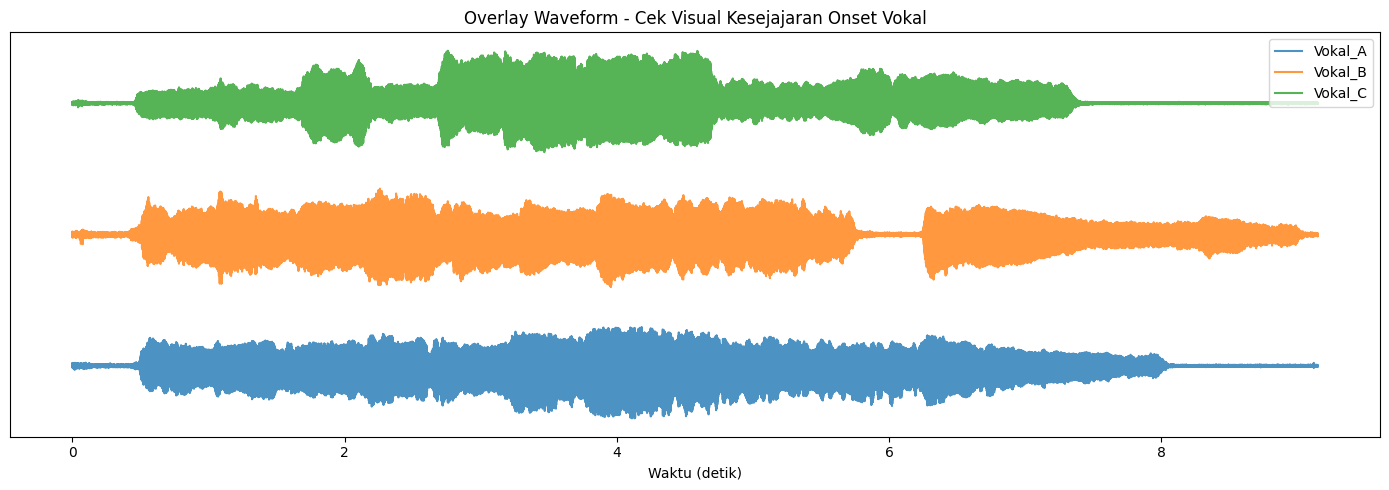

Ringkasan yang ditampilkan di plot:
  Vokal_A: durasi 9.150s, onset (amplitudo > 5% puncak) terdeteksi di 0.001s
  Vokal_B: durasi 9.150s, onset (amplitudo > 5% puncak) terdeteksi di 0.001s
  Vokal_C: durasi 9.150s, onset (amplitudo > 5% puncak) terdeteksi di 0.043s
Selisih onset terbesar antar file: 0.042s -> terlihat sejajar


In [8]:
# Sanity plot: overlay waveform ketiga file vokal (offset di sumbu Y biar kelihatan semua)
fig, ax = plt.subplots(figsize=(14, 5))
offset = 0
onset_times = {}
for name, (y, sr) in audio_cache.items():
    t = np.linspace(0, len(y) / sr, num=len(y))
    y_norm = y / (np.max(np.abs(y)) + 1e-9)  # normalisasi amplitude biar sebanding visual
    ax.plot(t, y_norm + offset, label=name, alpha=0.8)
    offset += 2.5
    onset_idx = int(np.argmax(np.abs(y_norm) > 0.05))
    onset_times[name] = onset_idx / sr

ax.set_xlabel("Waktu (detik)")
ax.set_yticks([])
ax.set_title("Overlay Waveform - Cek Visual Kesejajaran Onset Vokal")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print("Ringkasan yang ditampilkan di plot:")
for name in VOCAL_FILES.keys():
    dur = df_info.loc[df_info["file"] == name, "duration_sec"].values[0]
    print(f"  {name}: durasi {dur:.3f}s, onset (amplitudo > 5% puncak) terdeteksi di {onset_times[name]:.3f}s")
max_onset_diff = max(onset_times.values()) - min(onset_times.values())
print(f"Selisih onset terbesar antar file: {max_onset_diff:.3f}s -> "
      f"{'terlihat sejajar' if max_onset_diff < 0.3 else 'ada pergeseran, perhatikan saat interpretasi'}")


## 5. Tahap 1.5 — Deteksi Offset Otomatis

Karena vokal hanya mencakup ~9 detik dari suatu bagian di awal lagu (MIDI penuh berdurasi 266 detik) dan
belum dipotong manual, titik mulai bagian vokal di lagu MIDI penuh dideteksi otomatis via cross-correlation
kontur pitch (skala cents relatif). Pencarian dibatasi ke `OFFSET_SEARCH_RANGE_S` untuk menghindari
false positive (mis. di ujung lagu saat ritardango + not sustain gampang match secara kebetulan).

In [9]:
# Ground truth MIDI penuh (track Soprano saja) - dipakai sebagai basis pencarian offset
df_midi_full = midi_to_f0_contour(MIDI_FILE, HOP_S, instrument_filter="Soprano")
midi_f0_full = df_midi_full["f0_midi_hz"].values

# Cari offset presisi untuk ketiga file vokal
refined_offsets = {}
for name, (y, sr) in audio_cache.items():
    df_c = extract_f0_crepe(y, sr)
    vf0 = np.where(df_c["confidence"] >= CREPE_CONF_THRESHOLD, df_c["f0_hz"], np.nan)
    conf_mean = df_c["confidence"].mean()
    off, df_sc = find_best_offset_refined(vf0, midi_f0_full, HOP_S,
                                           search_range=OFFSET_SEARCH_RANGE_S,
                                           search_step_s=OFFSET_SEARCH_STEP_S)
    refined_offsets[name] = off
    print(f"{name}: offset presisi (dibatasi {OFFSET_SEARCH_RANGE_S}) = {off:.3f} detik, "
          f"score={df_sc['score'].max():.4f}, avg CREPE confidence={conf_mean:.3f}")


PERINGATAN: 470 frame terdeteksi overlap not (ambigu) -> di-set NaN, dikecualikan dari ground truth.
Vokal_A: offset presisi (dibatasi (0, 30)) = 10.350 detik, score=0.6460, avg CREPE confidence=0.784
Vokal_B: offset presisi (dibatasi (0, 30)) = 10.200 detik, score=0.5659, avg CREPE confidence=0.819
Vokal_C: offset presisi (dibatasi (0, 30)) = 10.300 detik, score=0.4042, avg CREPE confidence=0.731


In [10]:
# Kunci titik trim MIDI berdasarkan konvergensi offset (rata-rata ketiga file)
offset_values = list(refined_offsets.values())
final_trim_offset = float(np.mean(offset_values))

print("Offset per file:", refined_offsets)
print(f"Offset final yang dipakai untuk trim MIDI: {final_trim_offset:.3f} detik")
print(f"Rentang offset: {min(offset_values):.3f}s - {max(offset_values):.3f}s "
      f"(selisih {max(offset_values)-min(offset_values):.3f}s -> "
      f"{'OK, konvergen' if max(offset_values)-min(offset_values) < 1.0 else 'PERINGATAN: selisih besar'})")


Offset per file: {'Vokal_A': np.float64(10.35), 'Vokal_B': np.float64(10.200000000000001), 'Vokal_C': np.float64(10.3)}
Offset final yang dipakai untuk trim MIDI: 10.283 detik
Rentang offset: 10.200s - 10.350s (selisih 0.150s -> OK, konvergen)


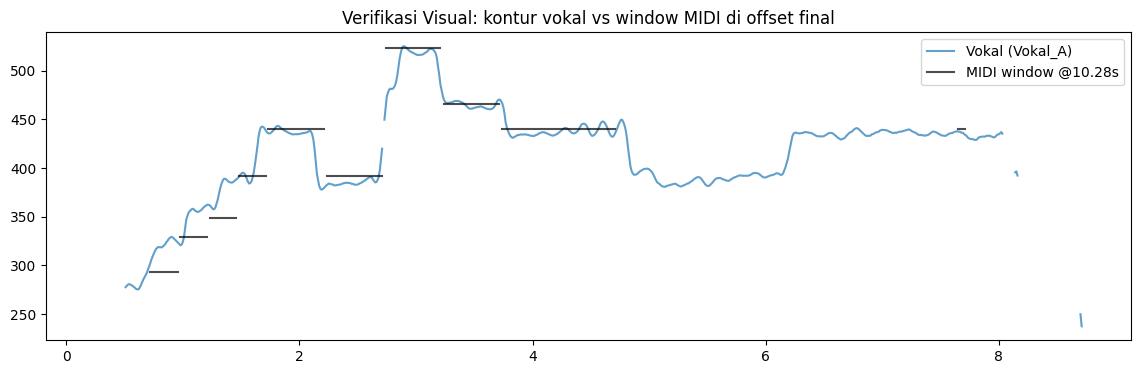

Plot menampilkan 915 frame (9.15 detik) kontur f0 Vokal_A vs window MIDI mulai 10.28s.
Frame dengan f0 valid di kedua sisi: 395/915 (43.2%). Korelasi bentuk kontur (skala cents relatif): 0.960 -> kecocokan bentuk kuat.


In [11]:
# Verifikasi visual: apakah kontur vokal (contoh: file pertama) cocok dengan window MIDI di offset final?
sample_name = list(VOCAL_FILES.keys())[0]
y, sr = audio_cache[sample_name]
df_c_sample = extract_f0_crepe(y, sr)
vocal_f0_sample = np.where(df_c_sample["confidence"] >= CREPE_CONF_THRESHOLD, df_c_sample["f0_hz"], np.nan)

window_frames = len(vocal_f0_sample)
start_idx = int(round(final_trim_offset / HOP_S))
midi_window = midi_f0_full[start_idx:start_idx + window_frames]

plt.figure(figsize=(14, 4))
t = np.arange(window_frames) * HOP_S
plt.plot(t, vocal_f0_sample, label=f"Vokal ({sample_name})", alpha=0.7)
plt.plot(t, midi_window, label=f"MIDI window @{final_trim_offset:.2f}s", alpha=0.7, color="black")
plt.legend()
plt.title("Verifikasi Visual: kontur vokal vs window MIDI di offset final")
plt.show()

valid_mask = ~np.isnan(vocal_f0_sample) & ~np.isnan(midi_window) & (midi_window > 0)
n_valid = int(valid_mask.sum())
if n_valid > 1:
    v_cents = 1200 * np.log2(vocal_f0_sample[valid_mask] / np.nanmedian(vocal_f0_sample[valid_mask]))
    m_cents = 1200 * np.log2(midi_window[valid_mask] / np.nanmedian(midi_window[valid_mask]))
    corr = float(np.corrcoef(v_cents, m_cents)[0, 1])
else:
    corr = float("nan")

print(f"Plot menampilkan {window_frames} frame ({window_frames * HOP_S:.2f} detik) kontur f0 {sample_name} "
      f"vs window MIDI mulai {final_trim_offset:.2f}s.")
print(f"Frame dengan f0 valid di kedua sisi: {n_valid}/{window_frames} "
      f"({100 * n_valid / window_frames:.1f}%). Korelasi bentuk kontur (skala cents relatif): {corr:.3f} "
      f"-> {'kecocokan bentuk kuat' if corr > 0.5 else 'kecocokan lemah, perlu ditinjau ulang'}.")


## 6. Tahap 2 — Nada Referensi MIDI (Trimmed)

Ambil `df_midi_full` (ground truth track Soprano, full 266 detik, sudah dengan overlap-not dikecualikan)
→ filter ke window `[final_trim_offset, final_trim_offset + durasi_vokal_terpanjang + buffer]`
→ reset waktu ke 0 supaya sejajar dengan waktu vokal.

In [12]:
TRIM_OFFSET = final_trim_offset

# Ambil durasi vokal terpanjang di antara 3 file sebagai acuan window
max_vocal_duration = max(librosa.get_duration(y=y, sr=sr) for y, sr in audio_cache.values())
trim_duration = max_vocal_duration + BUFFER_S

print(f"Trim MIDI dari detik {TRIM_OFFSET:.3f} sampai {TRIM_OFFSET + trim_duration:.3f} "
      f"(durasi window: {trim_duration:.3f}s)")

mask = (df_midi_full["time"] >= TRIM_OFFSET) & (df_midi_full["time"] < TRIM_OFFSET + trim_duration)
df_midi_gt = df_midi_full[mask].copy()
df_midi_gt["time"] = df_midi_gt["time"] - TRIM_OFFSET  # reset waktu ke 0
df_midi_gt = df_midi_gt.reset_index(drop=True)

print(f"\nTotal frame setelah trim: {len(df_midi_gt)}")
print(f"Frame dengan not aktif: {df_midi_gt['f0_midi_hz'].notna().sum()}")
df_midi_gt.head(10)


Trim MIDI dari detik 10.283 sampai 20.433 (durasi window: 10.150s)

Total frame setelah trim: 1015
Frame dengan not aktif: 424


,time,midi_note,f0_midi_hz,note_count
0,0.006667,NaN,NaN,0
1,0.016667,NaN,NaN,0
2,0.026667,NaN,NaN,0
3,0.036667,NaN,NaN,0
4,0.046667,NaN,NaN,0
5,0.056667,NaN,NaN,0
6,0.066667,NaN,NaN,0
7,0.076667,NaN,NaN,0
8,0.086667,NaN,NaN,0
9,0.096667,NaN,NaN,0


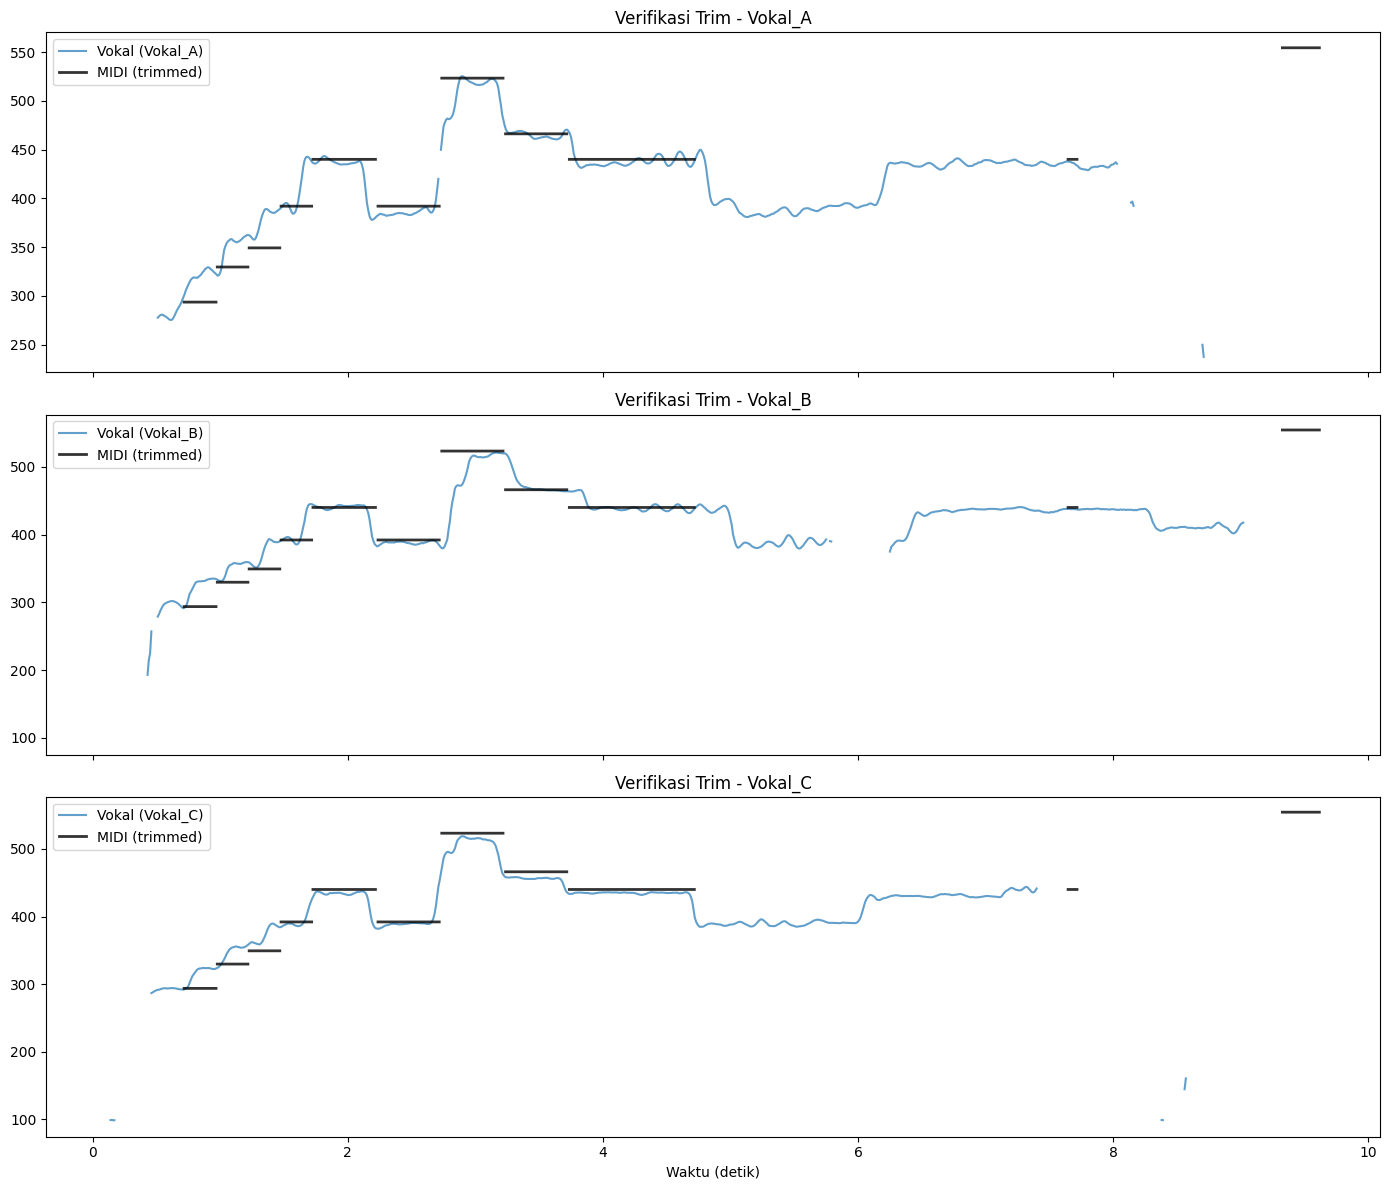

Ringkasan tiap panel (durasi vokal vs cakupan MIDI ground truth setelah trim):
  Vokal_A: durasi vokal 9.15s, MIDI ground truth tersedia sampai 10.15s (424 frame dengan not aktif dari total 1015 frame).
  Vokal_B: durasi vokal 9.15s, MIDI ground truth tersedia sampai 10.15s (424 frame dengan not aktif dari total 1015 frame).
  Vokal_C: durasi vokal 9.15s, MIDI ground truth tersedia sampai 10.15s (424 frame dengan not aktif dari total 1015 frame).


In [13]:
# Verifikasi: overlay ulang vokal vs MIDI yang sudah di-trim, cek kecocokan visual
fig, axes = plt.subplots(len(VOCAL_FILES), 1, figsize=(14, 4 * len(VOCAL_FILES)), sharex=True)
for ax, (name, (y, sr)) in zip(axes, audio_cache.items()):
    df_c = extract_f0_crepe(y, sr)
    vf0 = np.where(df_c["confidence"] >= CREPE_CONF_THRESHOLD, df_c["f0_hz"], np.nan)
    ax.plot(df_c["time"], vf0, label=f"Vokal ({name})", alpha=0.7)
    ax.plot(df_midi_gt["time"], df_midi_gt["f0_midi_hz"], color="black", linewidth=2,
            label="MIDI (trimmed)", drawstyle="steps-post", alpha=0.8)
    ax.set_title(f"Verifikasi Trim - {name}")
    ax.legend()
axes[-1].set_xlabel("Waktu (detik)")
plt.tight_layout()
plt.show()

print("Ringkasan tiap panel (durasi vokal vs cakupan MIDI ground truth setelah trim):")
for name, (y, sr) in audio_cache.items():
    vocal_dur = librosa.get_duration(y=y, sr=sr)
    midi_dur_covered = df_midi_gt["time"].max()
    n_midi_active = df_midi_gt["f0_midi_hz"].notna().sum()
    print(f"  {name}: durasi vokal {vocal_dur:.2f}s, MIDI ground truth tersedia sampai {midi_dur_covered:.2f}s "
          f"({n_midi_active} frame dengan not aktif dari total {len(df_midi_gt)} frame).")


## 7. Tahap 3 — Ekstraksi f0 Vokal (CREPE + pYIN)

Dua model dipakai untuk validasi silang. Frame CREPE dengan `confidence < CREPE_CONF_THRESHOLD`
dan frame pYIN yang `voiced_flag == False` di-set NaN (bukan pitch valid).

In [14]:
# --- CREPE ---
crepe_results = {}
for name, (y, sr) in audio_cache.items():
    print(f"Ekstraksi CREPE untuk {name} ...")
    df_c = extract_f0_crepe(y, sr)
    df_c["f0_hz_filtered"] = np.where(df_c["confidence"] >= CREPE_CONF_THRESHOLD, df_c["f0_hz"], np.nan)
    crepe_results[name] = df_c

print("\nSelesai ekstraksi CREPE untuk semua file.")
crepe_results[list(VOCAL_FILES.keys())[0]].head()


Ekstraksi CREPE untuk Vokal_A ...
Ekstraksi CREPE untuk Vokal_B ...
Ekstraksi CREPE untuk Vokal_C ...

Selesai ekstraksi CREPE untuk semua file.


,time,f0_hz,confidence,f0_hz_filtered
0,0.00,282.880429,0.059549,NaN
1,0.01,284.707513,0.083938,NaN
2,0.02,284.768098,0.212630,NaN
3,0.03,287.620238,0.191903,NaN
4,0.04,291.312498,0.235822,NaN


In [15]:
# --- pYIN ---
pyin_results = {}
for name, (y, sr) in audio_cache.items():
    print(f"Ekstraksi pYIN untuk {name} ...")
    pyin_results[name] = extract_f0_pyin(y, sr)

print("\nSelesai ekstraksi pYIN untuk semua file.")
pyin_results[list(VOCAL_FILES.keys())[0]].head()


Ekstraksi pYIN untuk Vokal_A ...
Ekstraksi pYIN untuk Vokal_B ...
Ekstraksi pYIN untuk Vokal_C ...

Selesai ekstraksi pYIN untuk semua file.


,time,f0_hz,voiced_flag,voiced_prob,f0_hz_filtered
0,0.00,NaN,False,0.010000,NaN
1,0.01,NaN,False,0.010000,NaN
2,0.02,NaN,False,0.010000,NaN
3,0.03,NaN,False,0.010003,NaN
4,0.04,NaN,False,0.010003,NaN


## 8. Tahap 4 — Alignment Waktu Vokal ↔ MIDI

**Default: DTW** (`USE_DTW = True`), untuk menangani drift lokal per not akibat perbedaan
timing/tempo penyanyi vs MIDI. `align_direct` (direct time-mapping) tersedia sebagai fallback/pembanding.

In [31]:
align_fn = align_dtw if USE_DTW else align_direct
print(f"Metode alignment dipakai: {'DTW' if USE_DTW else 'Direct time-mapping'}")

aligned_crepe = {name: align_fn(df, df_midi_gt) for name, df in crepe_results.items()}
aligned_pyin  = {name: align_fn(df, df_midi_gt) for name, df in pyin_results.items()}

aligned_crepe[list(VOCAL_FILES.keys())[0]].head()


Metode alignment dipakai: DTW


,time,f0_hz,confidence,f0_hz_filtered,f0_midi_hz,midi_note
0,0.00,282.880429,0.059549,NaN,NaN,NaN
1,0.01,284.707513,0.083938,NaN,NaN,NaN
2,0.02,284.768098,0.212630,NaN,NaN,NaN
3,0.03,287.620238,0.191903,NaN,NaN,NaN
4,0.04,291.312498,0.235822,NaN,NaN,NaN


In [32]:
# Cek proporsi frame yang berhasil ter-align dengan baik
for name in VOCAL_FILES.keys():
    total = len(aligned_crepe[name])
    valid = aligned_crepe[name]["f0_hz_filtered"].notna().sum()
    valid_and_midi = (aligned_crepe[name]["f0_hz_filtered"].notna() & aligned_crepe[name]["f0_midi_hz"].notna()).sum()
    print(f"{name}: total frame={total}, frame vokal valid={valid}, frame valid+ada MIDI={valid_and_midi}")


Vokal_A: total frame=915, frame vokal valid=758, frame valid+ada MIDI=393
Vokal_B: total frame=915, frame vokal valid=810, frame valid+ada MIDI=376
Vokal_C: total frame=915, frame vokal valid=711, frame valid+ada MIDI=403


In [33]:
##########################

# ===== DIAGNOSTIC: investigasi potensi distorsi rest-matching di DTW =====

print("=== 1. Rasio frame aktif GT, dibatasi ke rentang durasi vokal saja ===")
for name in VOCAL_FILES.keys():
    vocal_len = len(crepe_results[name])
    gt_window = df_midi_gt.iloc[:vocal_len]
    active_ratio = gt_window["f0_midi_hz"].notna().mean() * 100
    print(f"  {name}: {gt_window['f0_midi_hz'].notna().sum()}/{vocal_len} frame aktif ({active_ratio:.1f}%)")

print("\n=== 2. Bandingkan align_dtw vs align_direct (proporsi valid+ada MIDI) ===")
aligned_direct_check = {name: align_direct(df, df_midi_gt) for name, df in crepe_results.items()}
for name in VOCAL_FILES.keys():
    total = len(aligned_crepe[name])
    dtw_valid = (aligned_crepe[name]["f0_hz_filtered"].notna() & aligned_crepe[name]["f0_midi_hz"].notna()).sum()
    direct_valid = (aligned_direct_check[name]["f0_hz_filtered"].notna() & aligned_direct_check[name]["f0_midi_hz"].notna()).sum()
    print(f"  {name}: DTW valid+MIDI={dtw_valid}/{total} ({100*dtw_valid/total:.1f}%) | "
          f"Direct valid+MIDI={direct_valid}/{total} ({100*direct_valid/total:.1f}%)")

print("\n=== 3. Cek kompresi warping path DTW (contoh: file pertama) ===")
from librosa.sequence import dtw
sample_name = list(VOCAL_FILES.keys())[0]
v = crepe_results[sample_name]["f0_hz_filtered"].ffill().bfill().values
m = df_midi_gt["f0_midi_hz"].ffill().bfill().values
v_log = np.log2(np.clip(v, 1, None)).reshape(1, -1)
m_log = np.log2(np.clip(m, 1, None)).reshape(1, -1)
D, wp = dtw(X=v_log, Y=m_log, metric="euclidean")
wp = wp[::-1]

vi_all = [p[0] for p in wp]
mi_all = [p[1] for p in wp]
unique_mi = len(set(mi_all))
print(f"  Panjang vokal: {len(v)}, panjang MIDI GT: {len(m)}")
print(f"  Panjang warping path: {len(wp)}")
print(f"  Jumlah index MIDI unik yang dipakai: {unique_mi}/{len(m)} ({100*unique_mi/len(m):.1f}%)")
from collections import Counter
mi_counts = Counter(mi_all)
max_reuse = max(mi_counts.values())
print(f"  Index MIDI yang paling banyak dipakai ulang: {max_reuse} kali (mi={max(mi_counts, key=mi_counts.get)})")

=== 1. Rasio frame aktif GT, dibatasi ke rentang durasi vokal saja ===
  Vokal_A: 395/915 frame aktif (43.2%)
  Vokal_B: 395/915 frame aktif (43.2%)
  Vokal_C: 395/915 frame aktif (43.2%)

=== 2. Bandingkan align_dtw vs align_direct (proporsi valid+ada MIDI) ===
  Vokal_A: DTW valid+MIDI=393/915 (43.0%) | Direct valid+MIDI=395/915 (43.2%)
  Vokal_B: DTW valid+MIDI=376/915 (41.1%) | Direct valid+MIDI=395/915 (43.2%)
  Vokal_C: DTW valid+MIDI=403/915 (44.0%) | Direct valid+MIDI=388/915 (42.4%)

=== 3. Cek kompresi warping path DTW (contoh: file pertama) ===
  Panjang vokal: 915, panjang MIDI GT: 1015
  Panjang warping path: 1044
  Jumlah index MIDI unik yang dipakai: 1015/1015 (100.0%)
  Index MIDI yang paling banyak dipakai ulang: 11 kali (mi=223)


## 9. Tahap 5 — Hitung Metrik Deviasi (Cents)

`cents = 1200 * log2(f0_vokal / f0_midi)`, dengan octave-wrap correction. Dihitung hanya pada frame
yang: (a) lolos filter confidence/voiced, dan (b) MIDI sedang punya not aktif (bukan rest/overlap).

In [34]:
metric_rows = []
detail_frames = {}

for name in VOCAL_FILES.keys():
    s_crepe, d_crepe = compute_cents_metrics(aligned_crepe[name], label=f"{name} (CREPE)")
    s_pyin, d_pyin = compute_cents_metrics(aligned_pyin[name], label=f"{name} (pYIN)")
    metric_rows.append(s_crepe)
    metric_rows.append(s_pyin)
    detail_frames[(name, "CREPE")] = d_crepe
    detail_frames[(name, "pYIN")] = d_pyin

df_summary = pd.DataFrame(metric_rows)
df_summary


,label,n_valid_frames,n_octave_corrected,pct_octave_corrected,MACE_cents,RMS_cents,pct_in_tune
0,Vokal_A (CREPE),393,0,0.0,26.54,38.02,88.80
1,Vokal_A (pYIN),369,18,4.9,44.58,87.80,83.47
2,Vokal_B (CREPE),376,0,0.0,61.76,150.48,85.11
3,Vokal_B (pYIN),388,0,0.0,23.79,39.03,92.01
4,Vokal_C (CREPE),403,4,1.0,32.32,57.63,89.08
5,Vokal_C (pYIN),325,12,3.7,42.52,72.32,84.00


In [35]:
# Breakdown deviasi per not MIDI (untuk lihat pola: apakah nada tertentu konsisten meleset)
breakdown_rows = []
for (name, model), d in detail_frames.items():
    if len(d) == 0:
        continue
    g = d.groupby("midi_note")["cents_dev"].agg(["mean", "std", "count"]).reset_index()
    g["file"] = name
    g["model"] = model
    breakdown_rows.append(g)

df_breakdown = pd.concat(breakdown_rows, ignore_index=True)
df_breakdown = df_breakdown.sort_values(["file", "model", "midi_note"])
df_breakdown.head(20)


,midi_note,mean,std,count,file,model
0,62.0,47.410532,31.631876,5,Vokal_A,CREPE
1,64.0,-35.874602,22.980196,26,Vokal_A,CREPE
2,65.0,41.561407,17.678108,27,Vokal_A,CREPE
3,67.0,-21.999650,29.437964,90,Vokal_A,CREPE
4,69.0,-10.426400,16.148703,146,Vokal_A,CREPE
5,70.0,-1.094748,17.893910,54,Vokal_A,CREPE
6,72.0,-46.584973,60.740239,45,Vokal_A,CREPE
7,62.0,32.000000,28.635642,5,Vokal_A,pYIN
8,64.0,-34.074074,26.056043,27,Vokal_A,pYIN
9,65.0,42.592593,19.133658,27,Vokal_A,pYIN


## 10. Diagnostic Tambahan

Cek distribusi `cents_dev` per file/model (mean vs median, untuk deteksi anomali seperti bug overlap-not
yang ditemukan di sesi sebelumnya), dan jumlah frame overlap yang dikecualikan di Tahap 2.

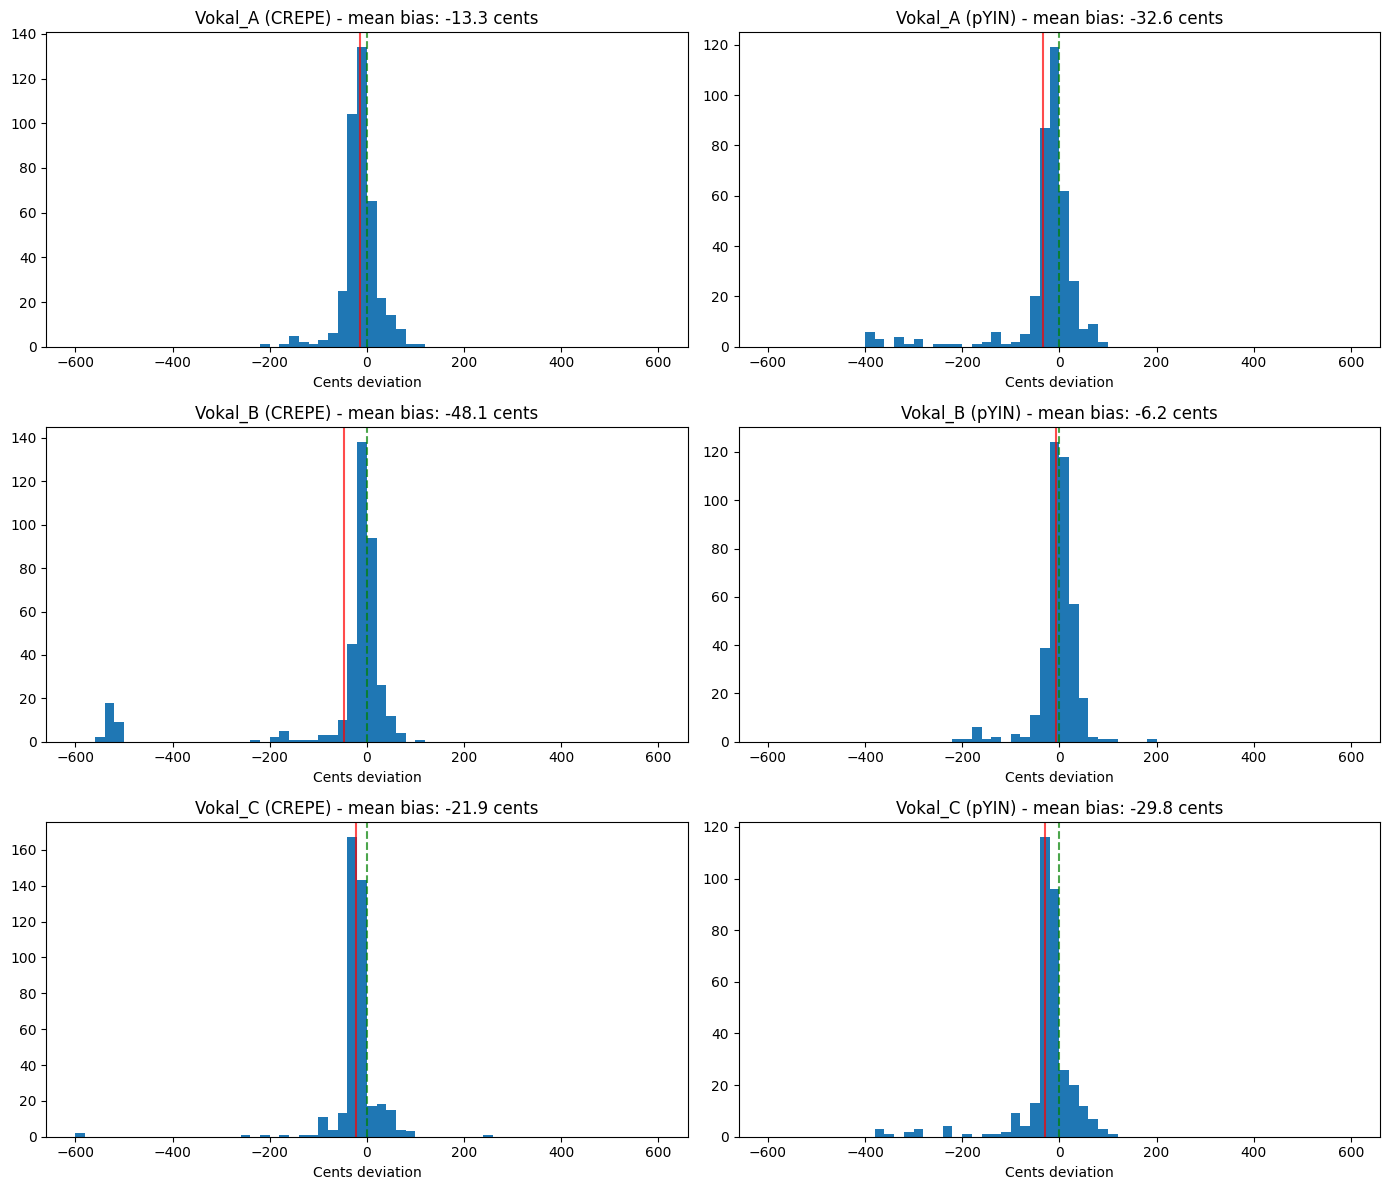

=== Mean SIGNED bias (bukan absolute) ===
Vokal_A (CREPE): mean signed bias = -13.31 cents, median = -15.01 cents
Vokal_A (pYIN): mean signed bias = -32.60 cents, median = -20.00 cents
Vokal_B (CREPE): mean signed bias = -48.13 cents, median = -8.29 cents
Vokal_B (pYIN): mean signed bias = -6.21 cents, median = 0.00 cents
Vokal_C (CREPE): mean signed bias = -21.86 cents, median = -20.01 cents
Vokal_C (pYIN): mean signed bias = -29.85 cents, median = -20.00 cents


In [36]:
# Histogram distribusi cents_dev per file/model
fig, axes = plt.subplots(len(VOCAL_FILES), 2, figsize=(14, 4 * len(VOCAL_FILES)))
for row, name in enumerate(VOCAL_FILES.keys()):
    for col, model in enumerate(["CREPE", "pYIN"]):
        d = detail_frames[(name, model)]
        ax = axes[row, col]
        ax.hist(d["cents_dev"], bins=60, range=(-600, 600))
        ax.axvline(0, color="green", linestyle="--", alpha=0.7)
        mean_signed = d["cents_dev"].mean()
        ax.axvline(mean_signed, color="red", linestyle="-", alpha=0.7)
        ax.set_title(f"{name} ({model}) - mean bias: {mean_signed:.1f} cents")
        ax.set_xlabel("Cents deviation")

plt.tight_layout()
plt.show()

print("=== Mean SIGNED bias (bukan absolute) ===")
for name in VOCAL_FILES.keys():
    for model in ["CREPE", "pYIN"]:
        d = detail_frames[(name, model)]
        print(f"{name} ({model}): mean signed bias = {d['cents_dev'].mean():.2f} cents, "
              f"median = {d['cents_dev'].median():.2f} cents")


In [37]:
# Jumlah frame overlap-not yang dikecualikan dari ground truth (di seluruh MIDI, sebelum trim)
n_overlap_total = (df_midi_full["note_count"] > 1).sum()

# Hitung ulang mask window yang sama seperti di Tahap 2, cek overlap di dalamnya
window_mask = (df_midi_full["time"] >= TRIM_OFFSET) & (df_midi_full["time"] < TRIM_OFFSET + trim_duration)
n_overlap_in_window = (df_midi_full.loc[window_mask, "note_count"] > 1).sum()

print(f"Total frame overlap-not di seluruh MIDI (track Soprano): {n_overlap_total}")
print(f"Frame overlap-not di dalam window trim yang dipakai: {n_overlap_in_window}")


Total frame overlap-not di seluruh MIDI (track Soprano): 470
Frame overlap-not di dalam window trim yang dipakai: 466


## 11. Tahap 6 — Visualisasi

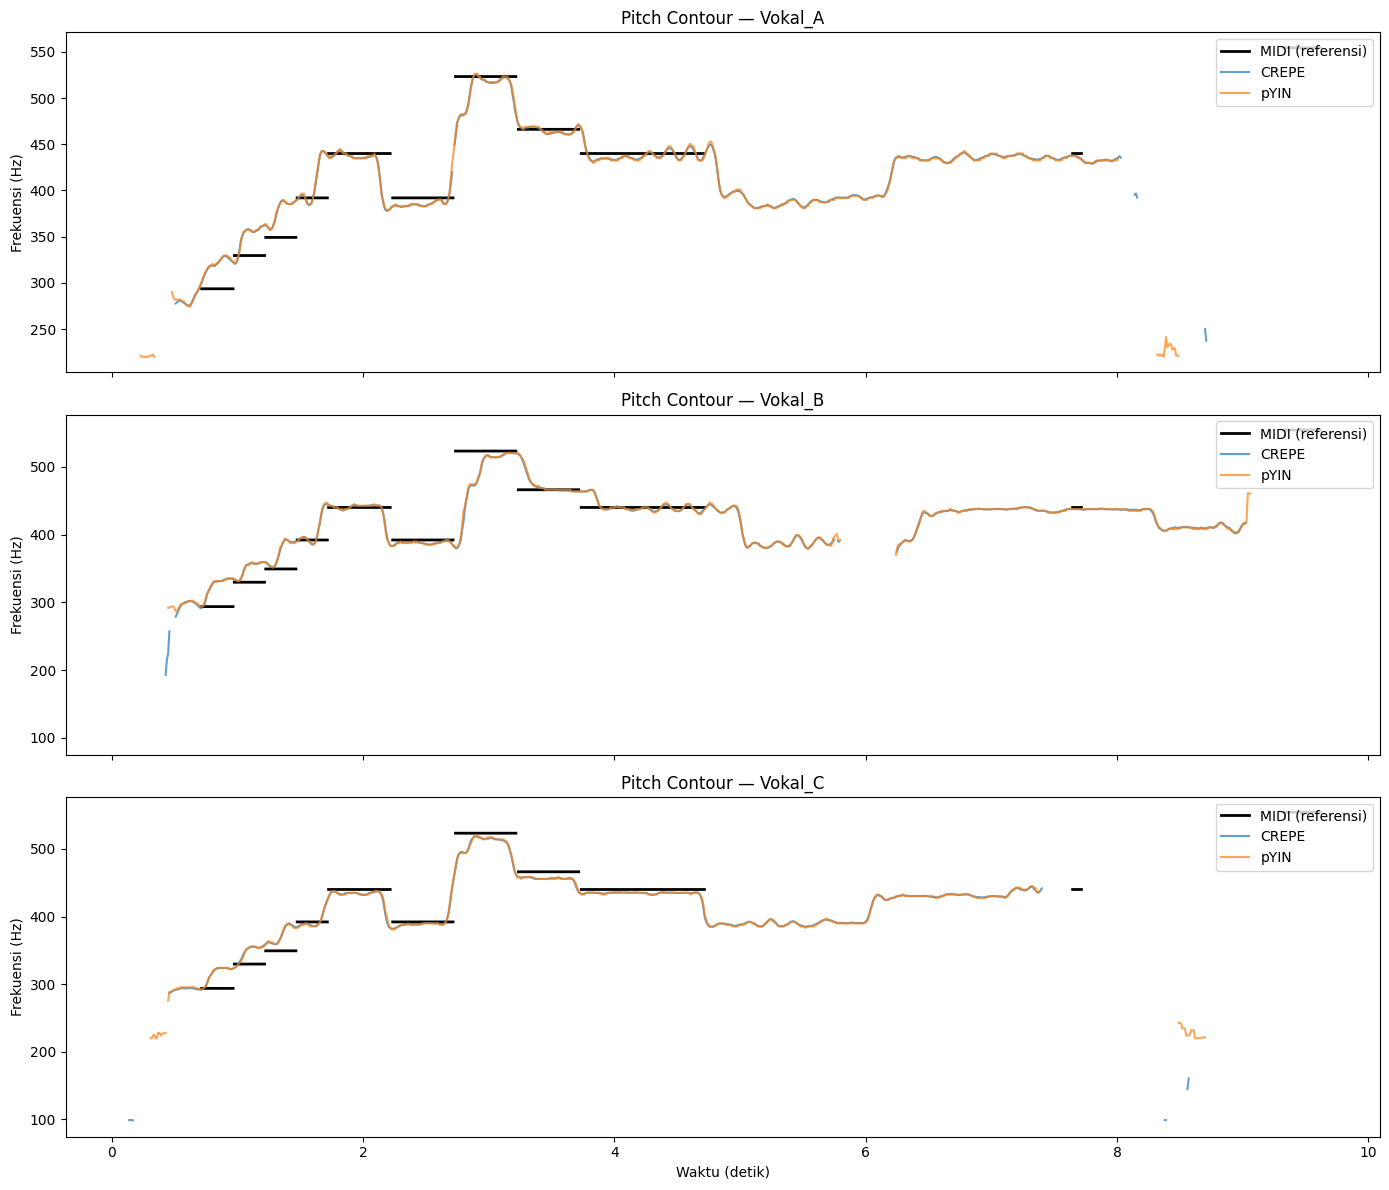

Seberapa dekat kontur biru (CREPE)/oranye (pYIN) mengikuti garis hitam (MIDI) di tiap panel, dinyatakan dalam angka (MACE = rata-rata deviasi absolut dalam cents; %in-tune = proporsi frame dalam +-50 cents):
  Vokal_A: CREPE MACE=26.5 cents, %in-tune=88.8% | pYIN MACE=44.6 cents, %in-tune=83.5%
  Vokal_B: CREPE MACE=61.8 cents, %in-tune=85.1% | pYIN MACE=23.8 cents, %in-tune=92.0%
  Vokal_C: CREPE MACE=32.3 cents, %in-tune=89.1% | pYIN MACE=42.5 cents, %in-tune=84.0%


In [38]:
# 1. Pitch contour overlay per file vokal: MIDI ground truth vs CREPE vs pYIN
fig, axes = plt.subplots(len(VOCAL_FILES), 1, figsize=(14, 4 * len(VOCAL_FILES)), sharex=True)
if len(VOCAL_FILES) == 1:
    axes = [axes]

for ax, name in zip(axes, VOCAL_FILES.keys()):
    ax.plot(df_midi_gt["time"], df_midi_gt["f0_midi_hz"], color="black", linewidth=2,
            label="MIDI (referensi)", drawstyle="steps-post")
    ax.plot(aligned_crepe[name]["time"], aligned_crepe[name]["f0_hz_filtered"],
            color="tab:blue", alpha=0.7, label="CREPE")
    ax.plot(aligned_pyin[name]["time"], aligned_pyin[name]["f0_hz_filtered"],
            color="tab:orange", alpha=0.7, label="pYIN")
    ax.set_title(f"Pitch Contour — {name}")
    ax.set_ylabel("Frekuensi (Hz)")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Waktu (detik)")
plt.tight_layout()
plt.show()

print("Seberapa dekat kontur biru (CREPE)/oranye (pYIN) mengikuti garis hitam (MIDI) di tiap panel, "
      "dinyatakan dalam angka (MACE = rata-rata deviasi absolut dalam cents; %in-tune = proporsi frame dalam +-50 cents):")
for name in VOCAL_FILES.keys():
    row_crepe = df_summary[df_summary["label"] == f"{name} (CREPE)"].iloc[0]
    row_pyin = df_summary[df_summary["label"] == f"{name} (pYIN)"].iloc[0]
    print(f"  {name}: CREPE MACE={row_crepe['MACE_cents']:.1f} cents, %in-tune={row_crepe['pct_in_tune']:.1f}% | "
          f"pYIN MACE={row_pyin['MACE_cents']:.1f} cents, %in-tune={row_pyin['pct_in_tune']:.1f}%")


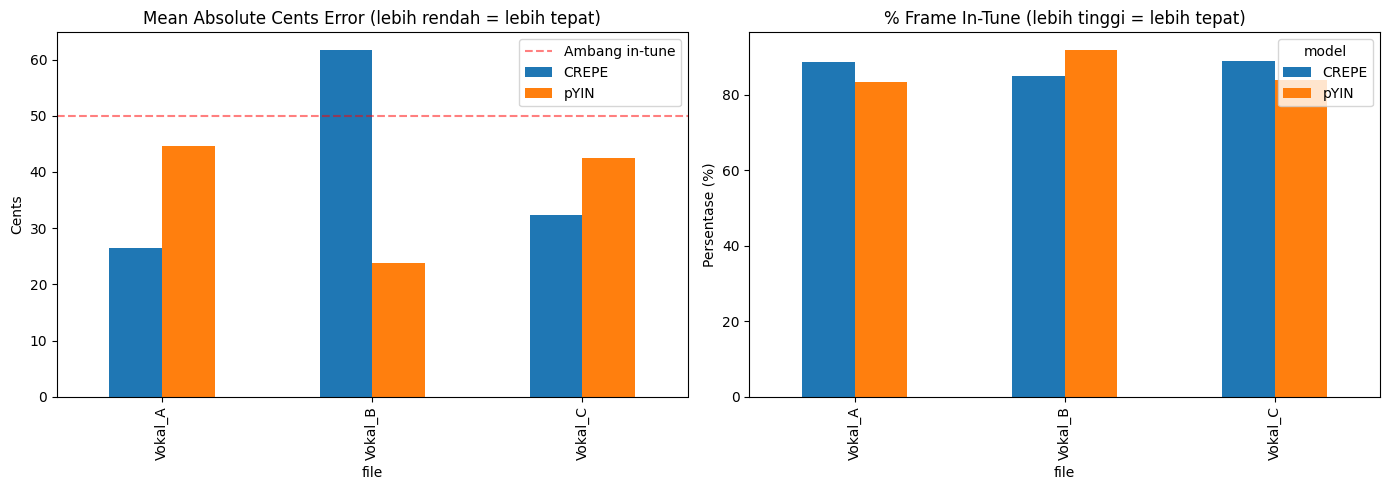

Nilai MACE (cents) per file x model, seperti ditampilkan di chart kiri:
model    CREPE   pYIN
file                 
Vokal_A  26.54  44.58
Vokal_B  61.76  23.79
Vokal_C  32.32  42.52

Nilai %in-tune per file x model, seperti ditampilkan di chart kanan:
model    CREPE   pYIN
file                 
Vokal_A  88.80  83.47
Vokal_B  85.11  92.01
Vokal_C  89.08  84.00

MACE terendah (paling tepat): Vokal_B (pYIN) = 23.8 cents
MACE tertinggi (paling meleset): Vokal_B (CREPE) = 61.8 cents


In [39]:
# 2. Bar chart perbandingan MACE dan %In-Tune antar file vokal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_summary["file"] = df_summary["label"].apply(lambda x: x.split(" (")[0])
df_summary["model"] = df_summary["label"].apply(lambda x: x.split("(")[1].replace(")", ""))

pivot1 = df_summary.pivot(index="file", columns="model", values="MACE_cents")
pivot1.plot(kind="bar", ax=axes[0])
axes[0].set_title("Mean Absolute Cents Error (lebih rendah = lebih tepat)")
axes[0].set_ylabel("Cents")
axes[0].axhline(INTUNE_CENTS_THRESHOLD, color="red", linestyle="--", alpha=0.5, label="Ambang in-tune")
axes[0].legend()

pivot2 = df_summary.pivot(index="file", columns="model", values="pct_in_tune")
pivot2.plot(kind="bar", ax=axes[1])
axes[1].set_title("% Frame In-Tune (lebih tinggi = lebih tepat)")
axes[1].set_ylabel("Persentase (%)")

plt.tight_layout()
plt.show()

print("Nilai MACE (cents) per file x model, seperti ditampilkan di chart kiri:")
print(pivot1.to_string())
print("\nNilai %in-tune per file x model, seperti ditampilkan di chart kanan:")
print(pivot2.to_string())

best_mace_file, best_mace_model = pivot1.stack().idxmin()
worst_mace_file, worst_mace_model = pivot1.stack().idxmax()
print(f"\nMACE terendah (paling tepat): {best_mace_file} ({best_mace_model}) = "
      f"{pivot1.loc[best_mace_file, best_mace_model]:.1f} cents")
print(f"MACE tertinggi (paling meleset): {worst_mace_file} ({worst_mace_model}) = "
      f"{pivot1.loc[worst_mace_file, worst_mace_model]:.1f} cents")


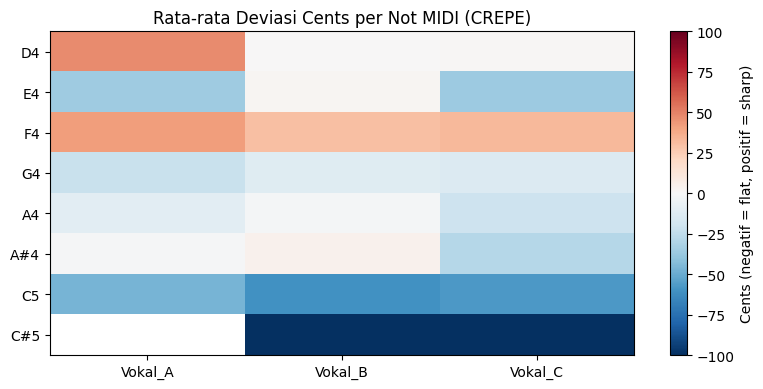

Heatmap menampilkan 8 not MIDI x 3 file (warna merah = sharp, biru = flat).
Deviasi paling positif (paling sharp): not D4 pada Vokal_A = 47.4 cents.
Deviasi paling negatif (paling flat): not C#5 pada Vokal_B = -524.3 cents.
Catatan: 1 sel kosong (NaN) -> kombinasi not-file tersebut tidak punya frame valid yang cukup.


In [40]:
# 3. Heatmap deviasi cents per not MIDI x per penyanyi (fokus ke hasil CREPE, model utama)
pivot_heat = df_breakdown[df_breakdown["model"] == "CREPE"].pivot_table(
    index="midi_note", columns="file", values="mean"
)

fig, ax = plt.subplots(figsize=(8, max(4, 0.3 * len(pivot_heat))))
im = ax.imshow(pivot_heat.values, aspect="auto", cmap="RdBu_r", vmin=-100, vmax=100)
ax.set_yticks(range(len(pivot_heat.index)))
ax.set_yticklabels([pretty_midi.note_number_to_name(int(n)) for n in pivot_heat.index])
ax.set_xticks(range(len(pivot_heat.columns)))
ax.set_xticklabels(pivot_heat.columns)
ax.set_title("Rata-rata Deviasi Cents per Not MIDI (CREPE)")
fig.colorbar(im, ax=ax, label="Cents (negatif = flat, positif = sharp)")
plt.tight_layout()
plt.show()

stacked = pivot_heat.stack()
max_note, max_file = stacked.idxmax()
min_note, min_file = stacked.idxmin()
print(f"Heatmap menampilkan {len(pivot_heat)} not MIDI x {len(pivot_heat.columns)} file "
      f"(warna merah = sharp, biru = flat).")
print(f"Deviasi paling positif (paling sharp): not {pretty_midi.note_number_to_name(int(max_note))} "
      f"pada {max_file} = {stacked.max():.1f} cents.")
print(f"Deviasi paling negatif (paling flat): not {pretty_midi.note_number_to_name(int(min_note))} "
      f"pada {min_file} = {stacked.min():.1f} cents.")
n_missing = int(pivot_heat.isna().sum().sum())
if n_missing > 0:
    print(f"Catatan: {n_missing} sel kosong (NaN) -> kombinasi not-file tersebut tidak punya frame valid yang cukup.")


## 12. Tahap 7 — Kesimpulan Kelayakan Model

Jawab pertanyaan awal: apakah CREPE/pYIN mumpuni sebagai alat tolak ukur ketepatan vokal?

In [41]:
print("=== RINGKASAN METRIK ===")
print(df_summary[["label", "n_valid_frames", "MACE_cents", "RMS_cents", "pct_in_tune"]].to_string(index=False))

print("\n=== CEK KONSISTENSI ANTAR MODEL ===")
ranking_crepe = df_summary[df_summary["model"] == "CREPE"].sort_values("MACE_cents")["file"].tolist()
ranking_pyin  = df_summary[df_summary["model"] == "pYIN"].sort_values("MACE_cents")["file"].tolist()
print("Ranking ketepatan (dari paling tepat) - CREPE:", ranking_crepe)
print("Ranking ketepatan (dari paling tepat) - pYIN :", ranking_pyin)
print("Konsisten?", "YA" if ranking_crepe == ranking_pyin else "TIDAK - perlu investigasi lebih lanjut")

print("\n=== CEK RELIABILITAS EKSTRAKSI ===")
for name in VOCAL_FILES.keys():
    conf_mean = crepe_results[name]["confidence"].mean()
    voiced_pct = pyin_results[name]["voiced_flag"].mean() * 100
    print(f"{name}: rata-rata CREPE confidence = {conf_mean:.2f}, "
          f"persentase frame voiced (pYIN) = {voiced_pct:.1f}%")

print("""
=== CATATAN INTERPRETASI ===
- Metrik di atas mengukur KESESUAIAN TERHADAP MIDI, bukan kualitas vokal secara umum.
  Vibrato/ekspresi musikal yang wajar bisa muncul sebagai 'deviasi' walau bukan kesalahan.
- Jika ranking CREPE & pYIN konsisten dan confidence/voiced rata-rata tinggi (>0.7 / >70%),
  ini indikasi kuat bahwa kedua model mumpuni dipakai sebagai alat tolak ukur untuk kasus ini.
- Jika ranking TIDAK konsisten, periksa dulu apakah ada file dengan confidence rendah
  (bisa jadi noise rekaman) atau pola anomali di df_breakdown (mis. bug overlap-not),
  sebelum menyimpulkan modelnya tidak layak.
""")


=== RINGKASAN METRIK ===
          label  n_valid_frames  MACE_cents  RMS_cents  pct_in_tune
Vokal_A (CREPE)             393       26.54      38.02        88.80
 Vokal_A (pYIN)             369       44.58      87.80        83.47
Vokal_B (CREPE)             376       61.76     150.48        85.11
 Vokal_B (pYIN)             388       23.79      39.03        92.01
Vokal_C (CREPE)             403       32.32      57.63        89.08
 Vokal_C (pYIN)             325       42.52      72.32        84.00

=== CEK KONSISTENSI ANTAR MODEL ===
Ranking ketepatan (dari paling tepat) - CREPE: ['Vokal_A', 'Vokal_C', 'Vokal_B']
Ranking ketepatan (dari paling tepat) - pYIN : ['Vokal_B', 'Vokal_C', 'Vokal_A']
Konsisten? TIDAK - perlu investigasi lebih lanjut

=== CEK RELIABILITAS EKSTRAKSI ===
Vokal_A: rata-rata CREPE confidence = 0.78, persentase frame voiced (pYIN) = 85.7%
Vokal_B: rata-rata CREPE confidence = 0.82, persentase frame voiced (pYIN) = 89.5%
Vokal_C: rata-rata CREPE confidence = 0.73, pers

## 13. Export Hasil
Simpan ringkasan metrik dan detail deviasi ke CSV untuk dokumentasi/laporan lebih lanjut.

In [42]:
df_summary.to_csv("summary_metrics.csv", index=False)
df_breakdown.to_csv("breakdown_per_note.csv", index=False)
print("Tersimpan: summary_metrics.csv, breakdown_per_note.csv")

from google.colab import files as gfiles
gfiles.download("summary_metrics.csv")
gfiles.download("breakdown_per_note.csv")


Tersimpan: summary_metrics.csv, breakdown_per_note.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>